In [1]:
import os, glob, re, pickle
from functools import partial
from collections import OrderedDict
import operator as op
from cytoolz import compose
import polars as pl
import pandas as pd
import seaborn as sns
import numpy as np
# import scanpy as sc
# import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt

from pyscenic.export import export2loom, add_scenic_metadata
from pyscenic.utils import load_motifs
from pyscenic.transform import df2regulons
from pyscenic.aucell import aucell
from pyscenic.polars_aucell import aucell_polars
from pyscenic.binarization import binarize
from pyscenic.rss import regulon_specificity_scores
from pyscenic.plotting import plot_binarization, plot_rss

from IPython.display import HTML, display

In [89]:
### AUX functs


BASE_URL = "http://motifcollections.aertslab.org/v9/logos/"
COLUMN_NAME_LOGO = "MotifLogo"
COLUMN_NAME_MOTIF_ID = "MotifID"
COLUMN_NAME_TARGETS = "TargetGenes"
GIT_DIR = "/rds/projects/g/gendood-3dmucosa/scRNAseqAnalysis/OralMucosa/VU40T_analysis/"
FIGURES_FOLDERNAME = "." # change to git_dir/Integrated/Plots when uploading to BEAR

In [3]:
def display_logos(df: pd.DataFrame, top_target_genes: int = 3, base_url: str = BASE_URL):
    df = df.copy()

    def create_url(motif_id):
        return f'<img src="{base_url}{motif_id}.png" style="max-height:124px;"></img>'
    df[("Enrichment", COLUMN_NAME_LOGO)] = list(map(create_url, df.index.get_level_values(COLUMN_NAME_MOTIF_ID)))

    def truncate(col_val):
        return sorted(col_val, key=op.itemgetter(1))[:top_target_genes]
    df[("Enrichment", COLUMN_NAME_TARGETS)] = list(map(truncate, df[("Enrichment", COLUMN_NAME_TARGETS)]))

    MAX_COL_WIDTH = pd.get_option('display.max_colwidth')
    pd.set_option('display.max_colwidth', None)  # <-- fix here
    display(HTML(df.head().to_html(escape=False)))
    pd.set_option('display.max_colwidth', MAX_COL_WIDTH)
    
def fetch_logo(regulon, base_url = BASE_URL):
    for elem in regulon.context:
        if elem.endswith('.png'):
            return '<img src="{}{}" style="max-height:124px;"></img>'.format(base_url, elem)
    return ""


In [90]:
def savesvg(fname: str, fig, folder: str=FIGURES_FOLDERNAME) -> None:
    """
    Save figure as vector-based SVG image format.
    """
    fig.tight_layout()
    fig.savefig(os.path.join(folder, fname), format='svg')

In [62]:
annots = pd.read_csv("epi_seurat_barcode_annotation.csv", index_col=0)
annots_series = annots.set_index(keys="barcode")
auc_mtx = pd.read_csv("human_epi_auc_mtx.csv", index_col=0)
annots_series = annots_series.sort_index(axis = 1, level = auc_mtx.index)
annots_series = annots_series["cluster"].astype(str)

display(annots_series)
print(annots_series.dtype)
display(auc_mtx)
print(annots_series.describe)

barcode
ATGCCAGCAACGTTCC-1_1    3
GCCATATGTCTTGCTC-1_1    3
GGCACACCATTGCGTC-1_1    3
CACCACCTCCGGGTAT-1_1    7
ATACCCTTCCGCATGG-1_1    3
                       ..
AGCATATTCGAATCCA-1_4    6
TGAGGCGGTTTAGTCA-1_4    6
TGCTCCATCCCAGTCC-1_4    6
CTTGGGACATTACCCA-1_4    6
CTATGTTCAACTTACT-1_4    6
Name: cluster, Length: 9520, dtype: object

object


,ARID3B(+),ARID5B(+),ATF1(+),ATF3(+),ATF4(+),ATF5(+),BACH1(+),BARX2(+),BCL6(+),BCLAF1(+),...,ZBTB7A(+),ZNF143(+),ZNF148(+),ZNF267(+),ZNF33A(+),ZNF571(+),ZNF580(+),ZNF615(+),ZNF654(+),ZNF792(+)
Cell,,,,,,,,,,,,,,,,,,,,,
ATGCCAGCAACGTTCC-1_1,0.055706,0.197664,0.360432,0.667354,0.236456,0.113317,0.243732,0.237371,0.164206,0.181418,...,0.208519,0.044184,0.270960,0.167155,0.111507,0.046334,0.168278,0.023829,0.111386,0.172063
GCCATATGTCTTGCTC-1_1,0.018858,0.307258,0.298569,0.684916,0.222550,0.108188,0.237356,0.267668,0.062967,0.187198,...,0.204979,0.000000,0.196184,0.194017,0.261824,0.077699,0.148988,0.000000,0.133692,0.185336
GGCACACCATTGCGTC-1_1,0.036509,0.225576,0.264115,0.604403,0.218194,0.113261,0.171880,0.235567,0.251315,0.172699,...,0.208153,0.110545,0.135579,0.165839,0.022177,0.000000,0.166000,0.041412,0.121569,0.074514
CACCACCTCCGGGTAT-1_1,0.063778,0.073536,0.258712,0.465296,0.223848,0.112532,0.207861,0.182268,0.098905,0.199030,...,0.204049,0.054537,0.207128,0.170706,0.000000,0.073625,0.178103,0.138357,0.128601,0.124026
ATACCCTTCCGCATGG-1_1,0.000000,0.127446,0.138776,0.546900,0.178241,0.034994,0.231396,0.218781,0.281441,0.198489,...,0.195601,0.123897,0.165189,0.126591,0.038074,0.073727,0.173545,0.182010,0.311900,0.169406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AGCATATTCGAATCCA-1_4,0.000000,0.019719,0.000000,0.205719,0.068717,0.028652,0.101737,0.089700,0.236719,0.076202,...,0.062387,0.000000,0.080605,0.133639,0.000000,0.000000,0.046550,0.087848,0.141160,0.122223
TGAGGCGGTTTAGTCA-1_4,0.000000,0.107480,0.000000,0.096119,0.097291,0.012371,0.059893,0.065007,0.000000,0.056017,...,0.049417,0.000000,0.043309,0.060832,0.000000,0.000000,0.031423,0.094976,0.000000,0.026594
TGCTCCATCCCAGTCC-1_4,0.110281,0.021138,0.000000,0.141467,0.048204,0.012321,0.102859,0.090472,0.000000,0.065796,...,0.057302,0.149525,0.071121,0.165831,0.000000,0.000000,0.039812,0.094094,0.142518,0.123475


<bound method NDFrame.describe of barcode
ATGCCAGCAACGTTCC-1_1    3
GCCATATGTCTTGCTC-1_1    3
GGCACACCATTGCGTC-1_1    3
CACCACCTCCGGGTAT-1_1    7
ATACCCTTCCGCATGG-1_1    3
                       ..
AGCATATTCGAATCCA-1_4    6
TGAGGCGGTTTAGTCA-1_4    6
TGCTCCATCCCAGTCC-1_4    6
CTTGGGACATTACCCA-1_4    6
CTATGTTCAACTTACT-1_4    6
Name: cluster, Length: 9520, dtype: object>


In [ ]:
### the counts csv produced by seurat in R is 1.06GB so convert to parquet to avoid crashes
with open("human_epi_counts.csv") as f:
    header = f.readline().strip().split(",")

# Assume first column is string, rest integers
dtypes = {col: pl.Int32 for col in header[1:]}
dtypes[header[0]] = pl.Utf8

lf = pl.scan_csv(
    "human_epi_counts.csv",
    schema_overrides=dtypes
)

lf.sink_parquet("human_epi_counts.parquet", compression="zstd")


/tmp/ipykernel_51036/913979716.py:9: DeprecationWarning: the argument `dtypes` for `scan_csv` is deprecated. It was renamed to `schema_overrides` in version 0.20.31.
  lf = pl.scan_csv(


In [5]:
## now read it back in to avoid crashing mem
counts_df = pl.read_parquet("human_epi_counts.parquet")

In [4]:
rss = regulon_specificity_scores(auc_mtx, annots_series)
rss

,ARID3B(+),ARID5B(+),ATF1(+),ATF3(+),ATF4(+),ATF5(+),BACH1(+),BARX2(+),BCL6(+),BCLAF1(+),...,ZBTB7A(+),ZNF143(+),ZNF148(+),ZNF267(+),ZNF33A(+),ZNF571(+),ZNF580(+),ZNF615(+),ZNF654(+),ZNF792(+)
3,0.265716,0.309681,0.289221,0.321382,0.318315,0.323480,0.313973,0.320962,0.304707,0.322667,...,0.318722,0.267347,0.322917,0.314515,0.307682,0.281949,0.327499,0.252040,0.291399,0.316629
7,0.186661,0.192416,0.194040,0.192955,0.193660,0.194726,0.192693,0.193609,0.195510,0.196422,...,0.194397,0.189426,0.195232,0.191805,0.188200,0.189058,0.196674,0.184448,0.189272,0.193688
4,0.267552,0.283182,0.287158,0.296282,0.295201,0.287443,0.294318,0.293487,0.270796,0.289748,...,0.294904,0.242888,0.290411,0.305497,0.278136,0.240296,0.289926,0.256480,0.281839,0.285967
2,0.334491,0.365240,0.340976,0.359065,0.336976,0.337923,0.345165,0.356555,0.309156,0.342784,...,0.341071,0.308011,0.341500,0.340181,0.264534,0.259379,0.337434,0.274598,0.345055,0.342665
5,0.250752,0.234166,0.268100,0.234005,0.250366,0.249808,0.250056,0.245154,0.246400,0.251521,...,0.252029,0.235052,0.253416,0.249418,0.226444,0.231702,0.252978,0.277822,0.251385,0.251890
1,0.326603,0.306997,0.333285,0.314618,0.338380,0.313361,0.330653,0.311695,0.282952,0.321350,...,0.331551,0.296315,0.321815,0.333890,0.254676,0.246560,0.322657,0.335605,0.318002,0.317011
0,0.356105,0.384642,0.371267,0.387472,0.380628,0.386698,0.382184,0.382551,0.350225,0.388698,...,0.382379,0.292133,0.386193,0.370912,0.282628,0.303618,0.386962,0.305451,0.369930,0.379924
6,0.187262,0.188861,0.184706,0.186433,0.189674,0.189559,0.192442,0.190316,0.184512,0.191227,...,0.189863,0.181828,0.191307,0.193214,0.180640,0.179864,0.189791,0.233463,0.191644,0.192751


/home/joshuad/miniconda3/envs/pyscenic/lib/python3.10/site-packages/pyscenic/plotting.py:22: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(auc_mtx[regulon_name], ax=ax, norm_hist=True, bins=bins)
/home/joshuad/miniconda3/envs/pyscenic/lib/python3.10/site-packages/pyscenic/plotting.py:22: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2

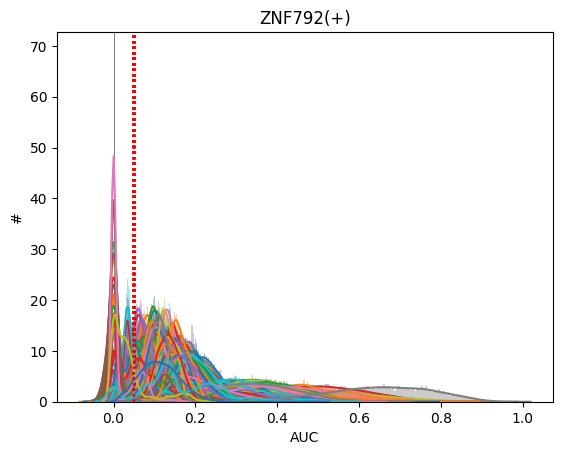

In [9]:
for col in auc_mtx.columns:
    plot_binarization(auc_mtx,  
                    regulon_name=col,
                    threshold=0.05
                    )

In [10]:
sns.set()
vmin = rss.values.min()
vmax = rss.values.max()
sns.set(style='whitegrid', font_scale=0.8)
fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(8, 6), dpi=300)
plot_rss(rss, '0', ax=ax1)
ax1.set_xlabel('')
plot_rss(rss, '1', ax=ax2)
ax2.set_xlabel('')
ax2.set_ylabel('')
plot_rss(rss, '2', ax=ax3)
ax3.set_xlabel('')
ax3.set_ylabel('')
plot_rss(rss, '3', ax=ax4)
ax4.set_xlabel('')
ax4.set_ylabel('')
plot_rss(rss, '4', ax=ax5)
plot_rss(rss, '5', ax=ax6)
ax6.set_ylabel('')
plot_rss(rss, '6', ax=ax7)
ax7.set_ylabel('')
plot_rss(rss, '7', ax=ax8)
ax8.set_ylabel('')
plt.tight_layout()
# savesvg('plots - GSE115978 - rss.svg', fig)

NameError: name 'rss' is not defined

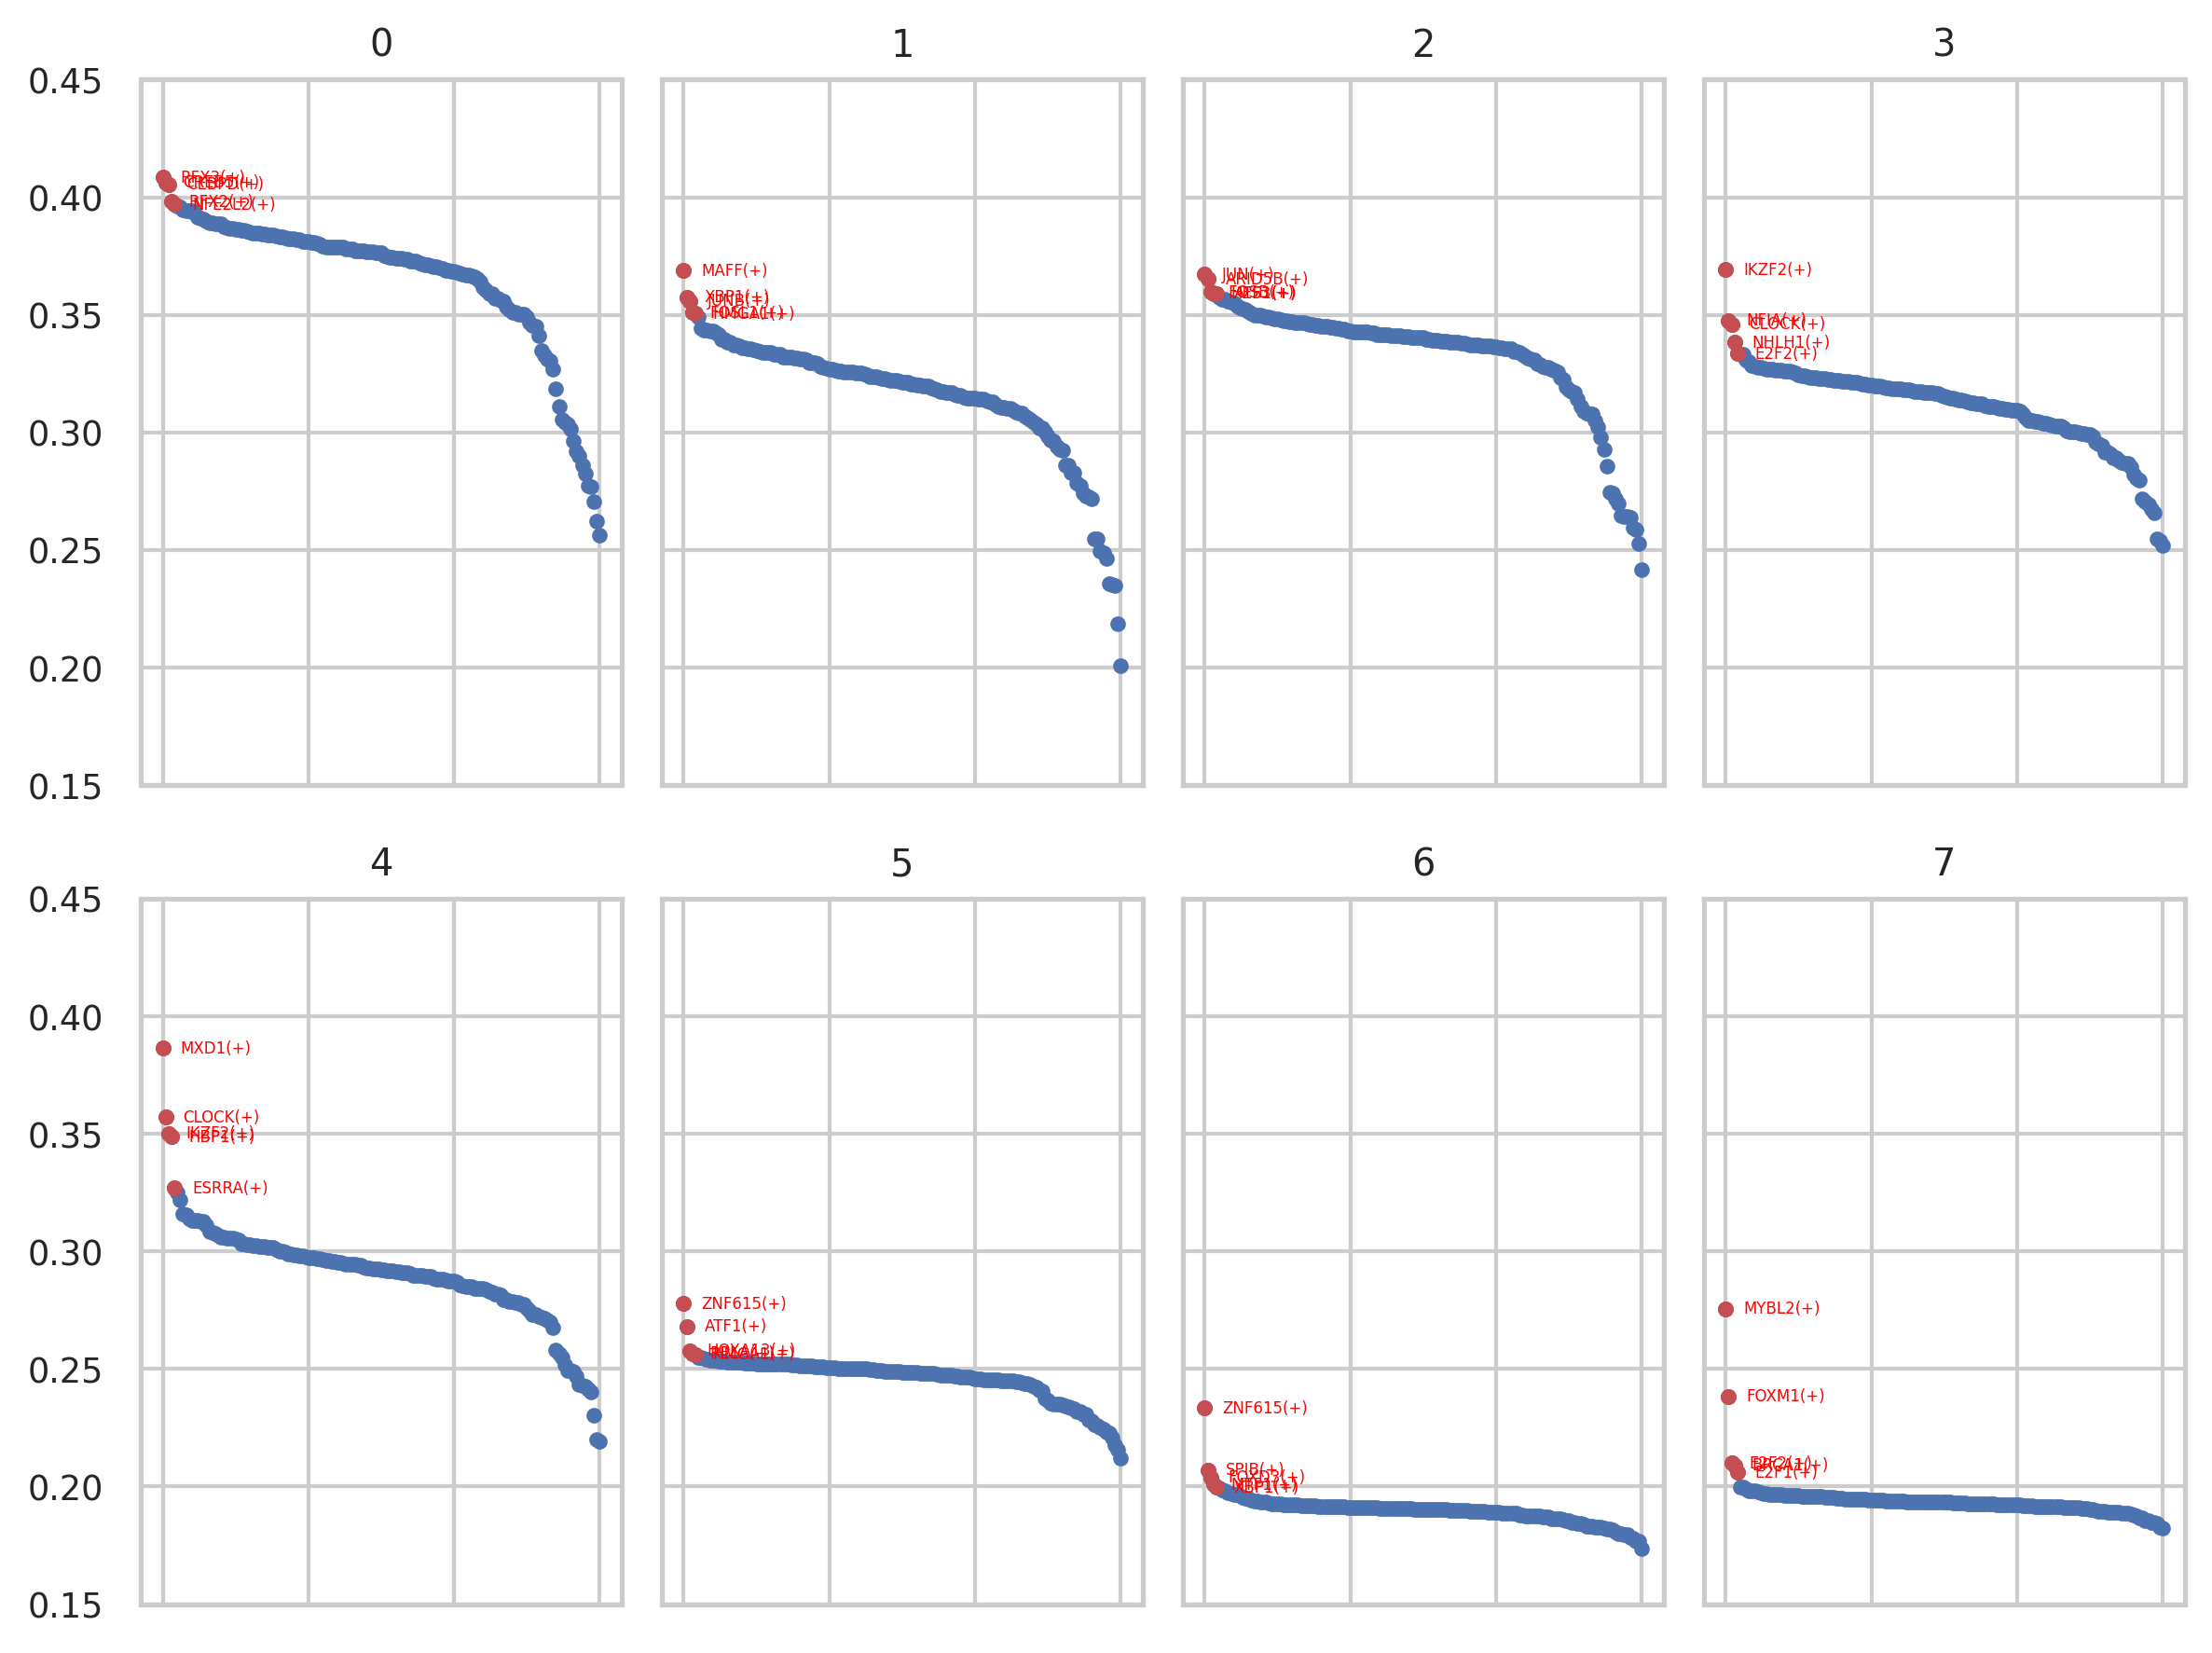

In [ ]:
sns.set(style='whitegrid', font_scale=0.8)
fig, axes = plt.subplots(2, 4, figsize=(8, 6), dpi=300, sharey=True)
axs = axes.ravel()

cts = ['0','1','2','3','4','5','6','7']
for ax, ct in zip(axs, cts):
    plot_rss(rss, ct, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('')  # leave one with ylabel if you want

# enforce identical y-scale everywhere
for ax in axs:
    ax.set_ylim(0.15, 0.45)

plt.tight_layout()


In [ ]:
max_n = rss.shape[1]
quartile = max_n/25
top_n = 5
rss.iloc[2,:].sort_values(ascending=False)[0:max_n]

rss.iloc[5,:].sort_values(ascending=False)[0:max_n]
cts = ['0','1','2','3','4','5','6','7']
for ct in cts:
    top_regs = (
        rss.T[ct]           # Series: regulon → RSS
        .sort_values(ascending=False)
        .head(top_n)
        .index.tolist()
    )
    print(ct, top_regs)

0 ['RFX3(+)', 'CREB5(+)', 'CEBPD(+)', 'RFX2(+)', 'NFE2L2(+)']
1 ['MAFF(+)', 'XBP1(+)', 'JUNB(+)', 'FOSL1(+)', 'HMGA1(+)']
2 ['JUN(+)', 'ARID5B(+)', 'FOSB(+)', 'HES1(+)', 'ATF3(+)']
3 ['IKZF2(+)', 'NFIA(+)', 'CLOCK(+)', 'NHLH1(+)', 'E2F2(+)']
4 ['MXD1(+)', 'CLOCK(+)', 'IKZF2(+)', 'HBP1(+)', 'ESRRA(+)']
5 ['ZNF615(+)', 'ATF1(+)', 'HOXA13(+)', 'RELA(+)', 'HMGA1(+)']
6 ['ZNF615(+)', 'SPIB(+)', 'FOXD3(+)', 'MTF1(+)', 'XBP1(+)']
7 ['MYBL2(+)', 'FOXM1(+)', 'E2F2(+)', 'BRCA1(+)', 'E2F1(+)']


In [5]:
motifs_df = load_motifs("human_epi_regulons.csv")

In [6]:
motifs_df ## 999 TFs
display_logos(motifs_df)

In [14]:
db_names =(
        'hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings',
        'hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings'
)

def contains(*elems):
        def f(context):
                return any(elem in context for elem in elems)
        return f

motifs = motifs_df.copy()
motifs.columns = motifs.columns.droplevel(0)

    # For the creation of regulons we only keep the 10-species databases and the activating modules. We also remove the
    # enriched motifs for the modules that were created using the method 'weight>50.0%' (because these modules are not part
    # of the default settings of modules_from_adjacencies anymore.
motifs = motifs[
        np.fromiter(map(compose(op.not_, contains('weight>50.0%')), motifs.Context), dtype=np.bool) & \
        np.fromiter(map(contains(*db_names), motifs.Context), dtype=np.bool) & \
        np.fromiter(map(contains('activating'), motifs.Context), dtype=np.bool)]




motifs = motifs[
        np.fromiter(map(compose(op.not_, contains('weight>50.0%')), motifs.Context), dtype=np.bool) & \
        np.fromiter(map(contains('activating'), motifs.Context), dtype=np.bool)]
regulons = list(filter(lambda r: len(r) >= 10, df2regulons(motifs[(motifs['NES'] >= 3.0) 
                                                                      & ((motifs['Annotation'] == 'gene is directly annotated')
                                                                        | (motifs['Annotation'].str.startswith('gene is orthologous to')
                                                                           & motifs['Annotation'].str.endswith('which is directly annotated for motif')))
                                                                     ])))
regulons = list(map(lambda r: r.rename(r.transcription_factor), regulons))


Create regulons from a dataframe of enriched features.
Additional columns saved: []


/tmp/ipykernel_51036/2520325660.py:18: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  np.fromiter(map(compose(op.not_, contains('weight>50.0%')), motifs.Context), dtype=np.bool) & \
/tmp/ipykernel_51036/2520325660.py:19: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  np.fromiter(map(contains(*db_names), motifs.Context), dtype=np.bool) & \
/tmp/ipyker

In [15]:
## dump 75 filtered regulons out of the 999 motifs as a pickle
with open('human_only_filtered_regulons.dat', 'wb') as f:
    pickle.dump(regulons, f)


In [7]:
regulons = pd.read_pickle(r'human_only_filtered_regulons.dat')

In [16]:
counts_df = counts_df.to_pandas(use_pyarrow_extension_array=True) 


In [43]:
df_regulons = pd.DataFrame(data=[list(map(op.attrgetter('name'), regulons)),
                                 list(map(len, regulons)),
                                 list(map(fetch_logo, regulons))], index=['name', 'count', 'logo']).T

In [46]:

MAX_COL_WIDTH = pd.get_option('display.max_colwidth')
pd.set_option('display.max_colwidth', 75)
display(HTML(df_regulons.head().to_html(escape=False)))
pd.set_option('display.max_colwidth', MAX_COL_WIDTH)
display(df_regulons)

,name,count,logo
0,ARID5B,10,
1,ATF3,32,
2,BCLAF1,158,
3,BRCA1,230,
4,CHD1,356,


,name,count,logo
0,ARID5B,10,"<img src=""http://motifcollections.aertslab.org..."
1,ATF3,32,"<img src=""http://motifcollections.aertslab.org..."
2,BCLAF1,158,"<img src=""http://motifcollections.aertslab.org..."
3,BRCA1,230,"<img src=""http://motifcollections.aertslab.org..."
4,CHD1,356,"<img src=""http://motifcollections.aertslab.org..."
...,...,...,...
70,ZNF148,243,"<img src=""http://motifcollections.aertslab.org..."
71,ZNF267,80,"<img src=""http://motifcollections.aertslab.org..."
72,ZNF571,10,"<img src=""http://motifcollections.aertslab.org..."
73,ZNF580,86,"<img src=""http://motifcollections.aertslab.org..."


In [35]:
%time
auc = aucell_polars(
    "human_epi_counts.parquet",
    signatures=regulons,
    index_name="",
    normalize=True,
    seed=1,
    num_workers=8,
    chunk_size=2000,
    transpose=True,   # rows are cells already
)
auc.to_csv("human_epi_auc_mtx_filtered.csv")

CPU times: user 1e+03 ns, sys: 1 μs, total: 2 μs
Wall time: 5.25 μs


Chunks:   0%|          | 0/30 [00:00<?, ?it/s]Less than 80% of the genes in ARID5B are present in the expression matrix.
Less than 80% of the genes in ATF3 are present in the expression matrix.
Less than 80% of the genes in E2F3 are present in the expression matrix.
Less than 80% of the genes in E2F7 are present in the expression matrix.
Less than 80% of the genes in FOXO3 are present in the expression matrix.
Less than 80% of the genes in BCLAF1 are present in the expression matrix.
Less than 80% of the genes in EGR1 are present in the expression matrix.
Less than 80% of the genes in BRCA1 are present in the expression matrix.
Less than 80% of the genes in GATAD1 are present in the expression matrix.
Less than 80% of the genes in JUND are present in the expression matrix.
Less than 80% of the genes in HMGA2 are present in the expression matrix.
Less than 80% of the genes in ELF1 are present in the expression matrix.
Less than 80% of the genes in CHD1 are present in the expression matr

In [64]:
df_regulons.name
regulons_names = df_regulons.name + "(+)"
auc_mtx
filtered_auc = auc_mtx.filter(regulons_names, axis = 1)


In [85]:
rss = regulon_specificity_scores(filtered_auc, annots_series)
rss

,ARID5B(+),ATF3(+),BCLAF1(+),BRCA1(+),CHD1(+),CLOCK(+),CREB5(+),CTCF(+),E2F1(+),E2F2(+),...,YBX1(+),YY1(+),ZBTB20(+),ZBTB43(+),ZBTB7A(+),ZNF148(+),ZNF267(+),ZNF571(+),ZNF580(+),ZNF792(+)
3,0.309681,0.321382,0.322667,0.327919,0.321973,0.346029,0.300619,0.318554,0.329914,0.333577,...,0.325431,0.321985,0.319982,0.321671,0.318722,0.322917,0.314515,0.281949,0.327499,0.316629
7,0.192416,0.192955,0.196422,0.209059,0.196329,0.188840,0.195955,0.194648,0.206046,0.210006,...,0.196433,0.195863,0.193359,0.191789,0.194397,0.195232,0.191805,0.189058,0.196674,0.193688
4,0.283182,0.296282,0.289748,0.278714,0.287559,0.357146,0.249039,0.293942,0.273265,0.284345,...,0.281890,0.291547,0.295554,0.314010,0.294904,0.290411,0.305497,0.240296,0.289926,0.285967
2,0.365240,0.359065,0.342784,0.332254,0.341687,0.311053,0.338713,0.341172,0.326550,0.329089,...,0.340758,0.338187,0.346715,0.346573,0.341071,0.341500,0.340181,0.259379,0.337434,0.342665
5,0.234166,0.234005,0.251521,0.254709,0.252519,0.230590,0.254175,0.251930,0.254891,0.251191,...,0.253494,0.252471,0.251027,0.243898,0.252029,0.253416,0.249418,0.231702,0.252978,0.251890
1,0.306997,0.314618,0.321350,0.315675,0.320108,0.321323,0.309608,0.326740,0.316169,0.310881,...,0.318516,0.328149,0.325381,0.322286,0.331551,0.321815,0.333890,0.246560,0.322657,0.317011
0,0.384642,0.387472,0.388698,0.392958,0.391167,0.331356,0.406217,0.383599,0.394703,0.385828,...,0.396198,0.386413,0.378782,0.370573,0.382379,0.386193,0.370912,0.303618,0.386962,0.379924
6,0.188861,0.186433,0.191227,0.190854,0.191237,0.194346,0.187063,0.192547,0.190858,0.195052,...,0.189149,0.190515,0.190489,0.189743,0.189863,0.191307,0.193214,0.179864,0.189791,0.192751


In [84]:
rss.loc[:, rss.max() > 0.4]
len(filtered_auc.loc[:, filtered_auc.max() > 0.4].columns)

31

In [97]:
new_auc = pd.read_csv("human_epi_auc_mtx_new.csv", index_col=0)
rss = regulon_specificity_scores(new_auc, annots_series)
rss

,ACAA1(+),ADNP2(-),AHR(+),ALX4(+),ALX4(-),ARID3A(+),ARID3A(-),ARID5B(+),ARID5B(-),ARNTL(-),...,ZNF782(-),ZNF783(-),ZNF789(+),ZNF790(+),ZNF836(+),ZNF846(-),ZSCAN2(-),ZSCAN26(+),ZSCAN5A(+),ZSCAN5A(-)
3,0.262532,0.307250,0.331975,0.296369,0.314308,0.313951,0.310608,0.309836,0.345234,0.252361,...,0.295498,0.308429,0.317972,0.314471,0.262910,0.316339,0.320060,0.264556,0.300570,0.323432
7,0.193797,0.193223,0.196247,0.192242,0.195033,0.191620,0.191581,0.193380,0.189427,0.187700,...,0.203853,0.192687,0.196348,0.194473,0.187294,0.194388,0.199382,0.205176,0.190671,0.196674
4,0.229221,0.295429,0.297351,0.286061,0.296455,0.292628,0.294706,0.289462,0.264795,0.286046,...,0.272556,0.295011,0.286107,0.286051,0.215740,0.285247,0.262951,0.233393,0.256833,0.266935
2,0.253268,0.344413,0.335860,0.331668,0.336422,0.325685,0.340128,0.355743,0.261305,0.339673,...,0.289735,0.343899,0.331931,0.330049,0.270806,0.339314,0.334397,0.258239,0.306655,0.316585
5,0.222020,0.243915,0.237752,0.249788,0.251117,0.252582,0.251415,0.249661,0.244619,0.250514,...,0.239708,0.251421,0.251300,0.251559,0.210696,0.251571,0.243650,0.232296,0.232126,0.246566
1,0.237296,0.306888,0.280113,0.342660,0.324018,0.342184,0.336800,0.318858,0.318856,0.358211,...,0.269416,0.333210,0.315481,0.297010,0.245702,0.326938,0.296921,0.243237,0.276605,0.310149
0,0.273228,0.355294,0.391510,0.375802,0.375345,0.370444,0.375155,0.389200,0.339122,0.374946,...,0.325691,0.377446,0.382370,0.355745,0.320195,0.387270,0.392617,0.287493,0.326233,0.372225
6,0.180366,0.189761,0.185090,0.196910,0.189377,0.188907,0.195271,0.192483,0.187134,0.214768,...,0.177824,0.188131,0.192172,0.187952,0.180423,0.192711,0.183131,0.180261,0.197087,0.188654


In [100]:
rss.index = rss.index.set_names("Cluster")


In [103]:
rss.to_csv("epi_pyscenic_regulon_specificity_scores_by_cluster.csv")

In [ ]:
rss = regulon_specificity_scores(filtered_auc, annots_series)
rss

,ARID5B(+),ATF3(+),BCLAF1(+),BRCA1(+),CHD1(+),CLOCK(+),CREB5(+),CTCF(+),E2F1(+),E2F2(+),...,YBX1(+),YY1(+),ZBTB20(+),ZBTB43(+),ZBTB7A(+),ZNF148(+),ZNF267(+),ZNF571(+),ZNF580(+),ZNF792(+)
3,0.309681,0.321382,0.322667,0.327919,0.321973,0.346029,0.300619,0.318554,0.329914,0.333577,...,0.325431,0.321985,0.319982,0.321671,0.318722,0.322917,0.314515,0.281949,0.327499,0.316629
7,0.192416,0.192955,0.196422,0.209059,0.196329,0.188840,0.195955,0.194648,0.206046,0.210006,...,0.196433,0.195863,0.193359,0.191789,0.194397,0.195232,0.191805,0.189058,0.196674,0.193688
4,0.283182,0.296282,0.289748,0.278714,0.287559,0.357146,0.249039,0.293942,0.273265,0.284345,...,0.281890,0.291547,0.295554,0.314010,0.294904,0.290411,0.305497,0.240296,0.289926,0.285967
2,0.365240,0.359065,0.342784,0.332254,0.341687,0.311053,0.338713,0.341172,0.326550,0.329089,...,0.340758,0.338187,0.346715,0.346573,0.341071,0.341500,0.340181,0.259379,0.337434,0.342665
5,0.234166,0.234005,0.251521,0.254709,0.252519,0.230590,0.254175,0.251930,0.254891,0.251191,...,0.253494,0.252471,0.251027,0.243898,0.252029,0.253416,0.249418,0.231702,0.252978,0.251890
1,0.306997,0.314618,0.321350,0.315675,0.320108,0.321323,0.309608,0.326740,0.316169,0.310881,...,0.318516,0.328149,0.325381,0.322286,0.331551,0.321815,0.333890,0.246560,0.322657,0.317011
0,0.384642,0.387472,0.388698,0.392958,0.391167,0.331356,0.406217,0.383599,0.394703,0.385828,...,0.396198,0.386413,0.378782,0.370573,0.382379,0.386193,0.370912,0.303618,0.386962,0.379924
6,0.188861,0.186433,0.191227,0.190854,0.191237,0.194346,0.187063,0.192547,0.190858,0.195052,...,0.189149,0.190515,0.190489,0.189743,0.189863,0.191307,0.193214,0.179864,0.189791,0.192751


In [115]:
rss_pos = rss.loc[:, [col for col in rss.columns if "(+)" in col]]
rss_pos

,ACAA1(+),AHR(+),ALX4(+),ARID3A(+),ARID5B(+),ATF1(+),ATF2(+),ATF3(+),ATF4(+),ATF5(+),...,ZNF740(+),ZNF76(+),ZNF77(+),ZNF777(+),ZNF780A(+),ZNF789(+),ZNF790(+),ZNF836(+),ZSCAN26(+),ZSCAN5A(+)
Cluster,,,,,,,,,,,,,,,,,,,,,
3,0.262532,0.331975,0.296369,0.313951,0.309836,0.309398,0.281099,0.320855,0.316142,0.322751,...,0.304687,0.327094,0.294263,0.285130,0.276377,0.317972,0.314471,0.262910,0.264556,0.300570
7,0.193797,0.196247,0.192242,0.191620,0.193380,0.194031,0.186002,0.193043,0.193870,0.194989,...,0.191444,0.197586,0.194134,0.190850,0.192595,0.196348,0.194473,0.187294,0.205176,0.190671
4,0.229221,0.297351,0.286061,0.292628,0.289462,0.290618,0.260681,0.294637,0.292591,0.290353,...,0.258602,0.298037,0.276477,0.275279,0.246495,0.286107,0.286051,0.215740,0.233393,0.256833
2,0.253268,0.335860,0.331668,0.325685,0.355743,0.338608,0.275972,0.360586,0.337602,0.340055,...,0.328157,0.336171,0.329602,0.296059,0.285359,0.331931,0.330049,0.270806,0.258239,0.306655
5,0.222020,0.237752,0.249788,0.252582,0.249661,0.261480,0.227361,0.232528,0.250239,0.249349,...,0.242468,0.249556,0.248142,0.247986,0.238266,0.251300,0.251559,0.210696,0.232296,0.232126
1,0.237296,0.280113,0.342660,0.342184,0.318858,0.335269,0.262372,0.312125,0.339611,0.319295,...,0.292517,0.313436,0.316175,0.263175,0.281486,0.315481,0.297010,0.245702,0.243237,0.276605
0,0.273228,0.391510,0.375802,0.370444,0.389200,0.378631,0.300415,0.389141,0.379560,0.386264,...,0.346037,0.381176,0.358784,0.300852,0.309530,0.382370,0.355745,0.320195,0.287493,0.326233
6,0.180366,0.185090,0.196910,0.188907,0.192483,0.191785,0.181022,0.187265,0.189481,0.189878,...,0.183382,0.186793,0.197148,0.184879,0.178083,0.192172,0.187952,0.180423,0.180261,0.197087


In [122]:
bin_mtx, thresholds = binarize(new_auc)
bin_mtx.to_csv("binarised_human_epi_auc_mtx_new.csv")
thresholds.to_frame().rename(columns={0:'threshold'}).to_csv("binarised_human_epi_thresholds_new.csv")

In [158]:
bin_mtx = pd.read_csv("binarised_human_epi_auc_mtx_new.csv", index_col=0)
thresholds = pd.read_csv("binarised_human_epi_thresholds_new.csv", index_col=0).threshold

In [ ]:
fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(8, 4), dpi=100)

plot_binarization(auc_mtx, 'NFKB2', thresholds['NFKB2'], ax=ax1)
plot_binarization(auc_mtx, 'MITF', thresholds['MITF'], ax=ax2)
plot_binarization(auc_mtx, 'FOXP3', thresholds['FOXP3'], ax=ax3)
plot_binarization(auc_mtx, 'PAX5', thresholds['PAX5'], ax=ax4)
plot_binarization(auc_mtx, 'IRF8', thresholds['IRF8'], ax=ax5)
plot_binarization(auc_mtx, 'IRF3', thresholds['IRF3'], ax=ax6)
plot_binarization(auc_mtx, 'MLX', thresholds['MLX'], ax=ax7)
plot_binarization(auc_mtx, 'YY1', thresholds['YY1'], ax=ax8)

plt.tight_layout()
# savesvg('hists - GSE115978 - binarization.svg', fig)

Cell,ATGCCAGCAACGTTCC-1_1,GCCATATGTCTTGCTC-1_1,GGCACACCATTGCGTC-1_1,CACCACCTCCGGGTAT-1_1,ATACCCTTCCGCATGG-1_1,CTAGGTCAGTCGCAAC-1_1,CCCTACGCAGGATCTG-1_1,ACCAAATTCTCACTTA-1_1,GGGTAAGTCCCTGGCT-1_1,GCAATCGCACCATGCT-1_1,...,ACCAACATCGCTAGGT-1_4,ATGGGCTTCGCTCCGT-1_4,CTTGCAGGTAGCGCAG-1_4,GCCTCCACATGAATGC-1_4,TAGGTTTAGGTATCCA-1_4,AGCATATTCGAATCCA-1_4,TGAGGCGGTTTAGTCA-1_4,TGCTCCATCCCAGTCC-1_4,CTTGGGACATTACCCA-1_4,CTATGTTCAACTTACT-1_4
ACAA1(+),0,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
ADNP2(-),0,1,0,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
AHR(+),1,1,0,0,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
ALX4(+),0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
ALX4(-),0,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF846(-),0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZSCAN2(-),1,1,1,1,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
ZSCAN26(+),0,0,0,0,1,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0
ZSCAN5A(+),0,1,1,1,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [46]:
def palplot(pal, names, colors=None, size=1):
    n = len(pal)
    f, ax = plt.subplots(1, 1, figsize=(n * size, size))
    ax.imshow(np.arange(n).reshape(1, n),
              cmap=mpl.colors.ListedColormap(list(pal)),
              interpolation="nearest", aspect="auto")
    ax.set_xticks(np.arange(n) - .5)
    ax.set_yticks([-.5, .5])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    colors = n * ['k'] if colors is None else colors
    for idx, (name, color) in enumerate(zip(names, colors)):
        ax.text(0.0+idx, 0.0, name, color=color, horizontalalignment='center', verticalalignment='center')
    return f

In [47]:

# 0) Make sure we’re plotting a pandas DataFrame of floats
X = bin_mtx.T
if not isinstance(X, pd.DataFrame):
    # e.g. Polars -> pandas
    X = X.to_pandas() if hasattr(X, "to_pandas") else pd.DataFrame(X)

# force numeric float (no object/nullable dtypes), remove infs
plot_df = (X.apply(pd.to_numeric, errors="coerce")
             .replace([np.inf, -np.inf], np.nan)
             .astype(np.float64))

# drop all-NaN rows/cols (SciPy linkage can’t handle them)
plot_df = plot_df.dropna(axis=0, how="all").dropna(axis=1, how="all")

# sanity: need at least 2 rows & 2 cols for clustering
if plot_df.shape[0] < 2 or plot_df.shape[1] < 2:
    raise ValueError(f"Too small after cleaning: {plot_df.shape}")

# 1) Build col_colors aligned to *these* columns
labels = annots_series.reindex(plot_df.columns)          # align to columns actually plotted
obs_clusters = pd.Index(pd.unique(labels.dropna())).sort_values()
palette = sns.color_palette("tab10", max(10, len(obs_clusters)))
lut = dict(zip(obs_clusters.astype(str), palette[:len(obs_clusters)]))
col_colors = labels.astype(str).map(lut).fillna("#cccccc")
col_colors_df = pd.DataFrame({"Cluster": col_colors}, index=plot_df.columns)

# 2) If you want to isolate which axis causes trouble, you can set one False:
# g = sns.clustermap(plot_df, col_colors=col_colors_df, row_cluster=False, cmap=bw_palette, figsize=(20,20))

# 3) Plot
g = sns.clustermap(
    plot_df,
    col_colors=col_colors_df,
    cmap=sns.bw_palette,
    figsize=(20, 20),
    xticklabels=False,
    yticklabels=False,
)

# tidy extras
axes = g.ax_col_colors if isinstance(g.ax_col_colors, list) else [g.ax_col_colors]
for ax in axes:
    if ax is not None:
        ax.set_yticks([0.5])
        ax.set_yticklabels(['Clusters'])
if getattr(g, "cax", None) is not None:
    g.cax.set_visible(False)

AttributeError: module 'seaborn' has no attribute 'bw_palette'

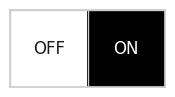

In [164]:
sns.set_theme()
sns.set_style("whitegrid")
fig = palplot(bw_palette, ['OFF', 'ON'], ['k', 'w'])
# savesvg('legend - GSE115978 - on_off.svg', fig)

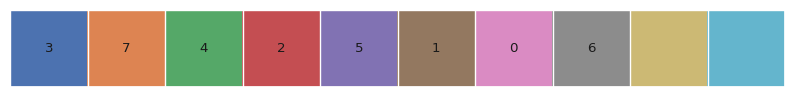

In [165]:
sns.set_theme()
sns.set_theme(font_scale=0.8)
fig = palplot(sns.color_palette(COLORS), annots_series.unique(), size=1.0)
# savesvg('legend - GSE115978 - cell_type_colors.svg', fig)

In [ ]:
new_auc

,ACAA1(+),ADNP2(-),AHR(+),ALX4(+),ALX4(-),ARID3A(+),ARID3A(-),ARID5B(+),ARID5B(-),ARNTL(-),...,ZNF782(-),ZNF783(-),ZNF789(+),ZNF790(+),ZNF836(+),ZNF846(-),ZSCAN2(-),ZSCAN26(+),ZSCAN5A(+),ZSCAN5A(-)
Cell,,,,,,,,,,,,,,,,,,,,,
ATGCCAGCAACGTTCC-1_1,0.000000,0.046334,0.487678,0.100107,0.237073,0.055382,0.201144,0.160243,0.025289,0.077975,...,0.000000,0.354421,0.100539,0.054209,0.112899,0.090778,0.382688,0.000000,0.030097,0.213267
GCCATATGTCTTGCTC-1_1,0.000000,0.172748,0.343652,0.264964,0.338708,0.041711,0.181505,0.181034,0.096130,0.000000,...,0.000000,0.484513,0.077064,0.056059,0.012899,0.222837,0.667957,0.000000,0.218375,0.347154
GGCACACCATTGCGTC-1_1,0.000000,0.096147,0.302749,0.048880,0.373755,0.099773,0.198154,0.129210,0.095961,0.000000,...,0.022290,0.529404,0.094312,0.116870,0.057570,0.108526,0.391310,0.000000,0.188561,0.103967
CACCACCTCCGGGTAT-1_1,0.031568,0.027269,0.240733,0.188787,0.274666,0.076574,0.160072,0.116988,0.094908,0.016778,...,0.031153,0.423328,0.091003,0.115037,0.000000,0.124657,0.327495,0.000000,0.098835,0.252497
ATACCCTTCCGCATGG-1_1,0.000000,0.165535,0.404718,0.188985,0.261796,0.072097,0.153202,0.144391,0.096775,0.062264,...,0.002772,0.442252,0.157332,0.134199,0.000000,0.139547,0.246572,0.078242,0.044014,0.172680


In [5]:
new_auc2 = pd.read_csv("pyscenic_fixed_human_epi_auc_mtx.csv", index_col=0)
new_auc2.shape

(9520, 621)

In [13]:
rss2 = regulon_specificity_scores(new_auc2, annots_series)
rss2.index = rss2.index.set_names("Cluster")


In [14]:
rss2.to_csv("pyscenic_fixed_human_epi_rss_by_cluster.csv")

In [15]:
### perform wilcoxon rank sum test between clusters for each regulon to find signif regulons per cluster


from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def find_cluster_specific_tfs(
    aucell: pd.DataFrame,
    clusters: pd.Series,
    top_n: int = 10,
    fdr_alpha: float | None = 0.05,
    min_cells: int = 10,
    pseudocount: float = 1e-9,
):
    """
    Identify cluster-specific TFs as those with the largest *decrease* in AUCell scores
    vs all other clusters, based on a one-sided Mann–Whitney U test (Wilcoxon rank-sum).

    Parameters
    ----------
    aucell : pd.DataFrame
        AUCell matrix of TF/regulon activity. Shape can be (TFs x cells) or (cells x TFs).
        Index/columns should be labeled; will auto-detect orientation.
    clusters : pd.Series
        Cluster annotation per cell (index = cell IDs, values = cluster labels).
    top_n : int
        Number of TFs to return per cluster (e.g., 10 or 15).
    fdr_alpha : float or None
        If set, apply Benjamini–Hochberg correction per cluster and keep TFs with q <= fdr_alpha.
        If None, do not filter by FDR.
    min_cells : int
        Minimum number of cells required *in the cluster* and *out of the cluster*.
    pseudocount : float
        Small value added when computing means to avoid division by zero.

    Returns
    -------
    results_per_cluster : dict[str, pd.DataFrame]
        For each cluster, a DataFrame with columns:
        ['TF', 'log2FC', 'pval', 'qval', 'cluster_mean', 'others_mean', 'n_in', 'n_out'],
        sorted by most negative log2FC. Top rows clipped to `top_n`.
    long_table : pd.DataFrame
        The full long-form table for all clusters (not clipped).
    """
    # --- Ensure orientation: rows=TFs, cols=cells ---
    if aucell.columns.equals(clusters.index):
        tf_by_cell = aucell
    elif aucell.index.equals(clusters.index):
        tf_by_cell = aucell.T
    else:
        # Try to align by intersection of cells
        common_cells = list(set(aucell.columns).intersection(set(clusters.index)))
        if len(common_cells) == 0:
            raise ValueError("No overlapping cell IDs between AUCell matrix and clusters Series.")
        tf_by_cell = aucell.loc[:, common_cells]
        clusters = clusters.loc[common_cells]

    # Sanity: ensure numeric
    tf_by_cell = tf_by_cell.apply(pd.to_numeric, errors="coerce")
    tf_by_cell = tf_by_cell.dropna(axis=0, how="any")  # drop TFs with NaNs across any cell
    tfs = tf_by_cell.index

    results = []
    for cl in clusters.unique():
        in_mask = clusters == cl
        out_mask = ~in_mask
        n_in = int(in_mask.sum())
        n_out = int(out_mask.sum())
        if n_in < min_cells or n_out < min_cells:
            # Skip clusters without enough cells on either side
            continue

        X = tf_by_cell.loc[:, in_mask]   # TFs x cells_in
        Y = tf_by_cell.loc[:, out_mask]  # TFs x cells_out

        # Means for log2FC
        cluster_mean = X.mean(axis=1)
        others_mean  = Y.mean(axis=1)
        log2fc = np.log2((cluster_mean + pseudocount) / (others_mean + pseudocount))

        # One-sided rank-sum: test if cluster < others (decrease in cluster)
        pvals = []
        for tf in tfs:
            try:
                stat, p = mannwhitneyu(X.loc[tf].values, Y.loc[tf].values, alternative="less")
            except ValueError:
                # If distributions are degenerate or identical
                p = 1.0
            pvals.append(p)
        pvals = np.asarray(pvals)

        # FDR per cluster
        if fdr_alpha is not None:
            _, qvals, _, _ = multipletests(pvals, alpha=fdr_alpha, method="fdr_bh")
        else:
            qvals = np.full_like(pvals, np.nan, dtype=float)

        df = pd.DataFrame({
            "TF": tfs,
            "log2FC": log2fc.values,
            "pval": pvals,
            "qval": qvals,
            "cluster_mean": cluster_mean.values,
            "others_mean": others_mean.values,
            "n_in": n_in,
            "n_out": n_out,
            "cluster": cl,
        }).sort_values("log2FC", ascending=True)  # most negative = largest decrease

        # Optional FDR filter before taking top N
        if fdr_alpha is not None:
            df = df[df["qval"] <= fdr_alpha]

        results.append(df)

    if not results:
        raise ValueError("No clusters passed min_cells thresholds or no overlapping cells.")

    long_table = pd.concat(results, axis=0, ignore_index=True)

    # Keep top_n per cluster
    results_per_cluster = {
        cl: grp.sort_values("log2FC", ascending=True).head(top_n).reset_index(drop=True)
        for cl, grp in long_table.groupby("cluster", sort=False)
    }

    return results_per_cluster, long_table


In [ ]:
top_n = 20  # or 10
res_per_cluster, full_table = find_cluster_specific_tfs(new_auc2, clusters = annots_series, top_n=top_n, fdr_alpha=0.05)

# Example: show top TFs for one cluster


,TF,log2FC,pval,qval,cluster_mean,others_mean,n_in,n_out,cluster
0,DDIT3(-),-1.102834,7.060382e-235,4.384498e-232,0.051711,0.111063,1296,8224,3
1,CEBPD(-),-1.044423,2.360548e-98,7.329501e-96,0.035640,0.073508,1296,8224,3
2,ZNF34(+),-0.567167,5.419299e-95,1.121795e-92,0.059564,0.088251,1296,8224,3
3,ZNF518A(-),-0.529639,3.096309e-85,4.807019e-83,0.043109,0.062230,1296,8224,3
4,MXD1(+),-0.503835,4.884097e-50,5.055040e-48,0.056955,0.080762,1296,8224,3


In [ ]:
res_per_cluster[list(res_per_cluster.keys())[0]]

{'3':             TF    log2FC           pval           qval  cluster_mean  \
 0     DDIT3(-) -1.102834  7.060382e-235  4.384498e-232      0.051711   
 1     CEBPD(-) -1.044423   2.360548e-98   7.329501e-96      0.035640   
 2     ZNF34(+) -0.567167   5.419299e-95   1.121795e-92      0.059564   
 3   ZNF518A(-) -0.529639   3.096309e-85   4.807019e-83      0.043109   
 4      MXD1(+) -0.503835   4.884097e-50   5.055040e-48      0.056955   
 5      KLF7(-) -0.452666   1.321728e-63   1.641586e-61      0.038649   
 6    TFAP2E(+) -0.384822   3.065947e-46   2.379941e-44      0.037684   
 7     FOXN2(-) -0.371091   8.271641e-37   4.669717e-35      0.031761   
 8      ILF2(-) -0.342836   3.349843e-37   2.080252e-35      0.036555   
 9    ZNF205(+) -0.316954   1.146809e-30   4.747789e-29      0.079144   
 10   ZNF836(-) -0.313918   1.066005e-08   1.697408e-07      0.061814   
 11   ZNF782(-) -0.310782   7.373448e-29   2.586904e-27      0.030899   
 12   TRIM28(-) -0.293695   7.914843e-29   2.5

In [21]:
# Combine per-cluster top results into one DataFrame
top_table = pd.concat(res_per_cluster.values(), ignore_index=True)


In [31]:
top_table.to_csv("pyscenic_fixed_human_epi_top_cluster_specific_tfs_wilcoxon_rank.csv")

In [36]:
### now binarise with the top 20 per cluster

unique_top_20_tfs = top_table.TF.unique()

new_auc2_filtered = new_auc2.loc[:, new_auc2.columns.intersection(unique_top_20_tfs)]

In [42]:
bin_mtx, thresholds = binarize(new_auc2_filtered)
bin_mtx.to_csv("binarised_human_epi_auc_mtx_top20perclust.csv")
thresholds.to_frame().rename(columns={0:'threshold'}).to_csv("binarised_human_epi_thresholds_top20perclust.csv")

In [96]:
bin_mtx = pd.read_csv("binarised_human_epi_auc_mtx_top20perclust.csv", index_col=0)
thresholds = pd.read_csv("binarised_human_epi_thresholds_top20perclust.csv", index_col=0).threshold

#cell_type_color_lut = dict(zip(adata.obs.cell_type.dtype.categories, adata.uns['cell_type_colors']))
cell_id2cell_type_lut = annots_series.to_dict()
bw_palette = sns.xkcd_palette(["white", "black"])
cell_id2cell_type_lut

N_COLORS = len(annots_series.unique())
COLORS = [color['color'] for color in mpl.rcParams["axes.prop_cycle"]][:int(N_COLORS)]
cell_type_color_lut = dict(zip(sorted(annots_series.unique(), key=int), COLORS))


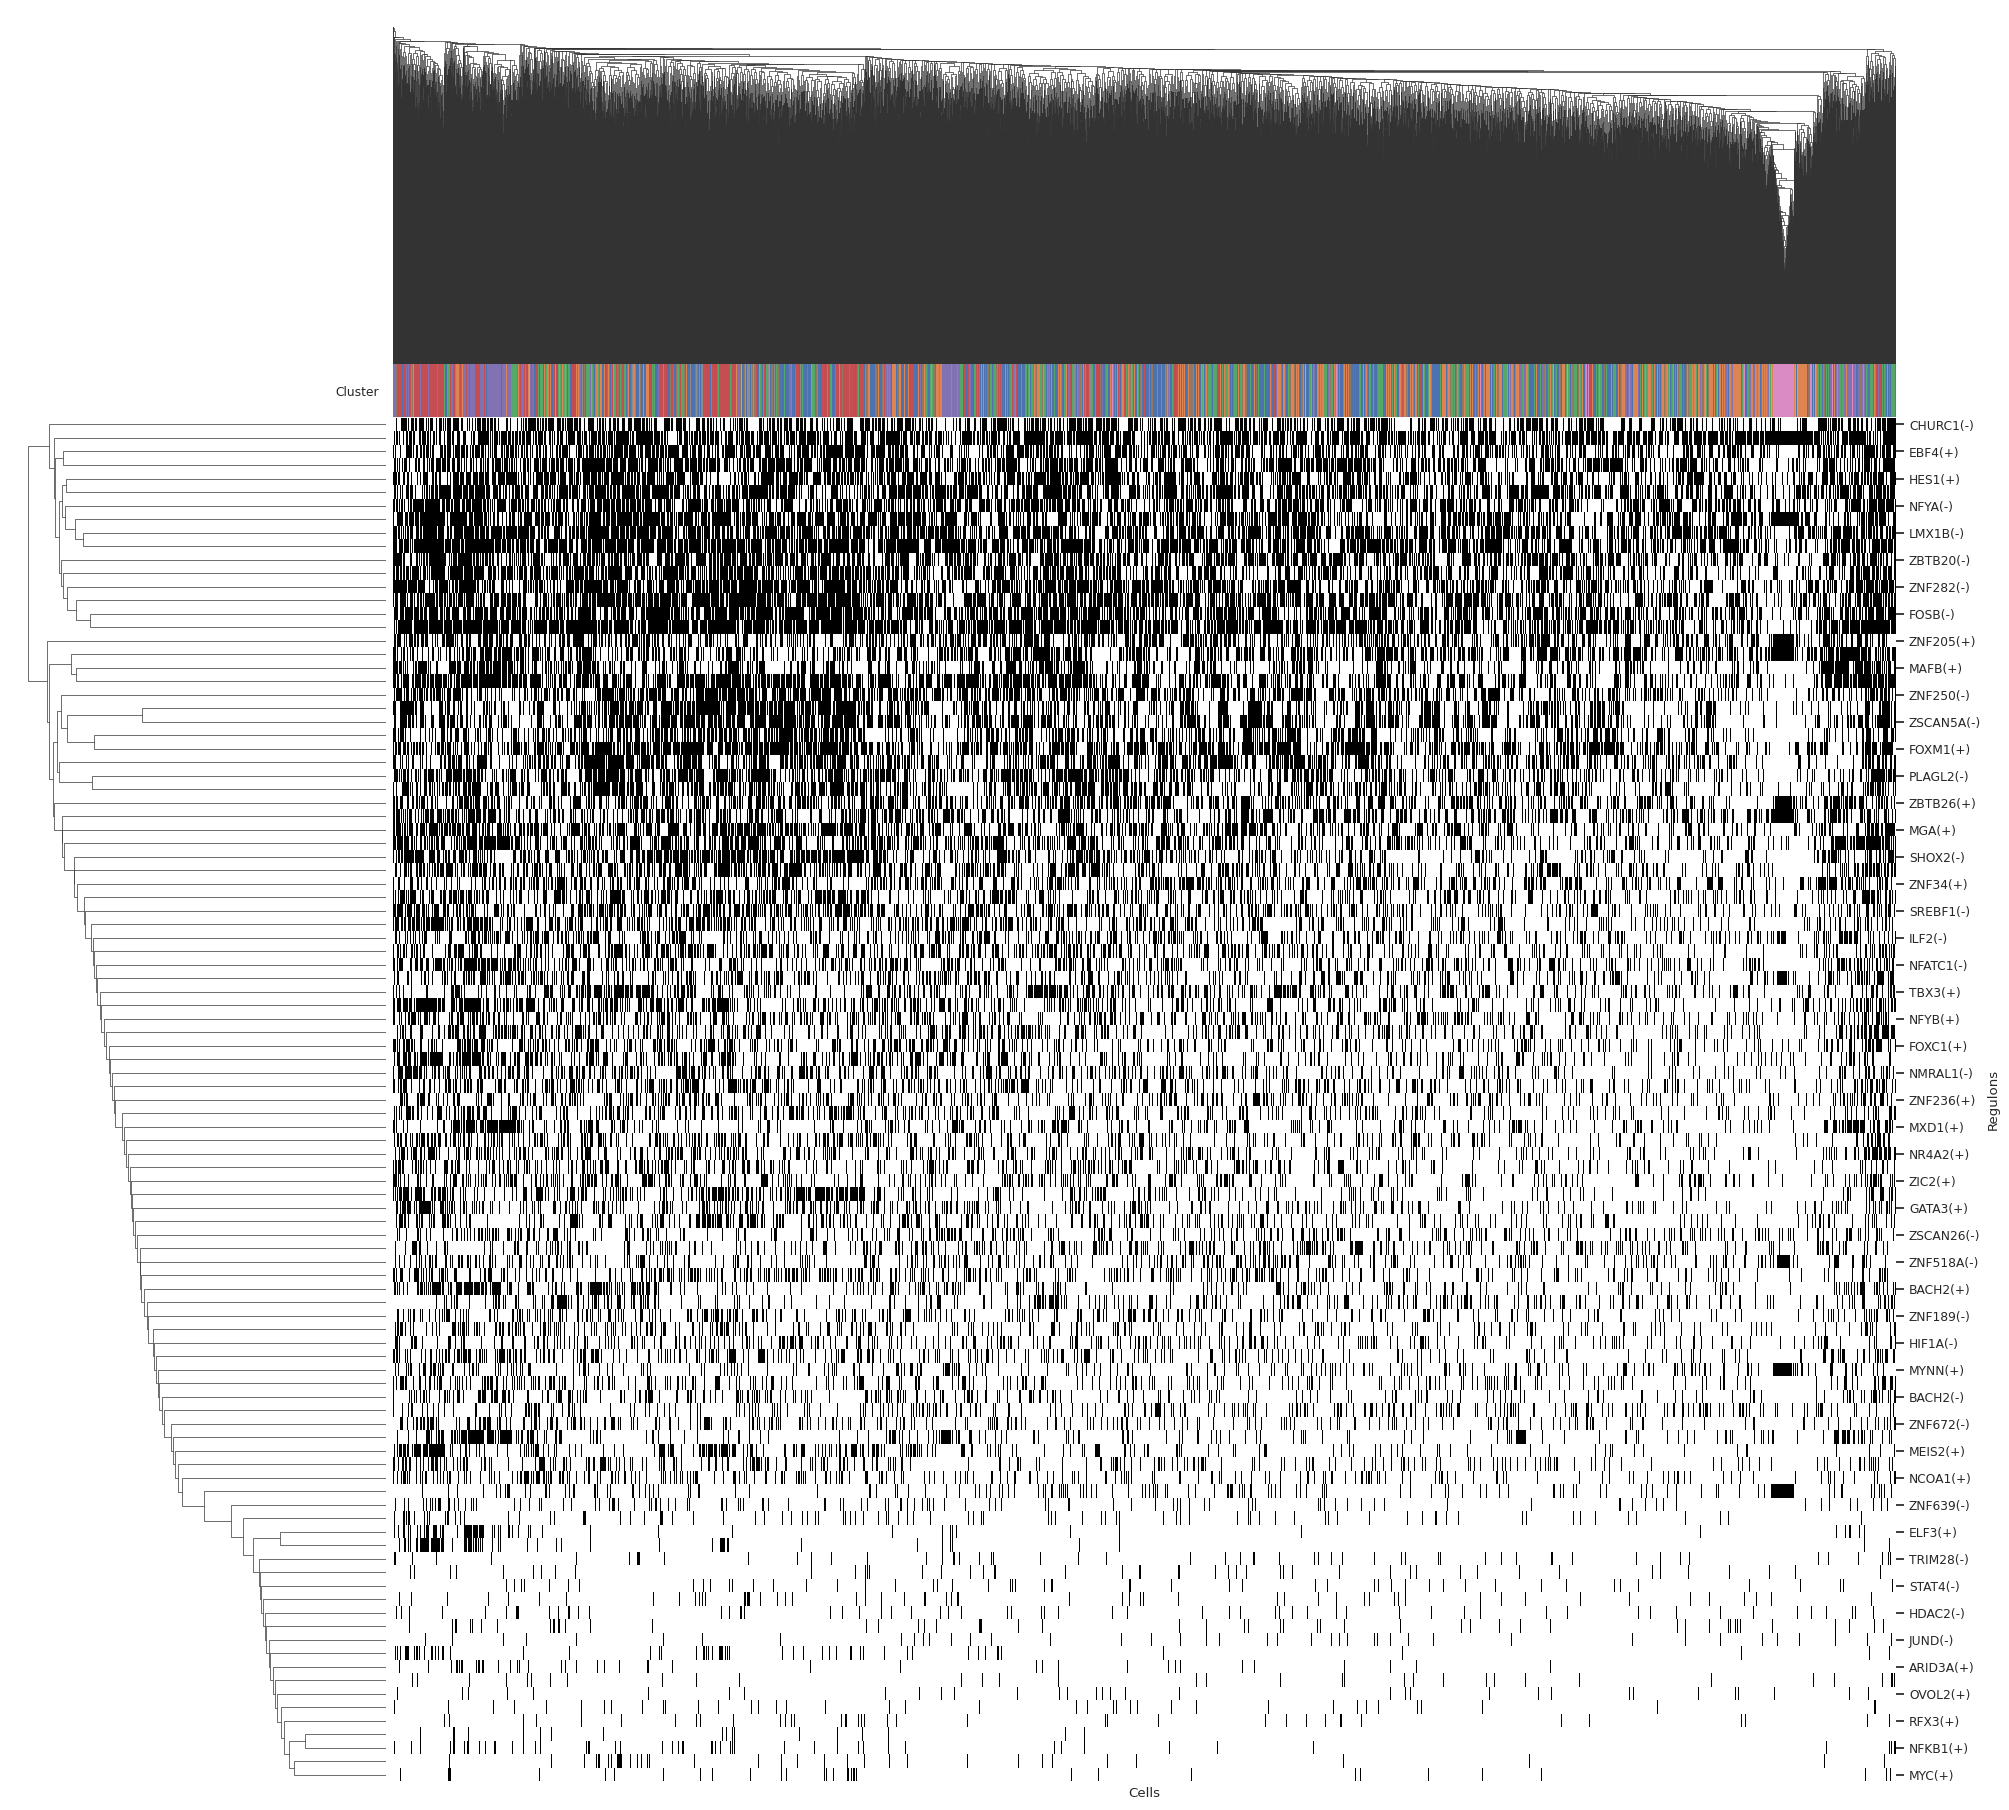

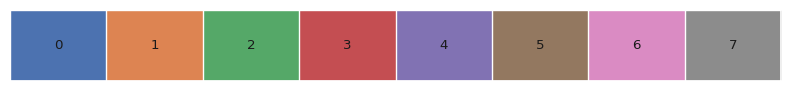

In [97]:
g = sns.clustermap(bin_mtx.T, 
               col_colors=auc_mtx.index.map(cell_id2cell_type_lut).map(cell_type_color_lut),
               cmap=bw_palette, figsize=(20,20))
g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xlabel('Cells')
g.ax_heatmap.set_ylabel('Regulons')
g.ax_col_colors.set_yticks([0.5])
g.ax_col_colors.set_yticklabels(['Cluster'])
g.cax.set_visible(False)
g.savefig(os.path.join(FIGURES_FOLDERNAME, 'clustermap_Top20_TFs_Pyscenic_HumanOnly_Epi.png'), format='png')


sns.set_theme()
sns.set_theme(font_scale=0.8)
fig = palplot(sns.color_palette(COLORS), sorted(annots_series.unique(), key=int), size=1.0)
savesvg('legendTop20_TFs_Pyscenic_HumanOnly_Epi', fig)


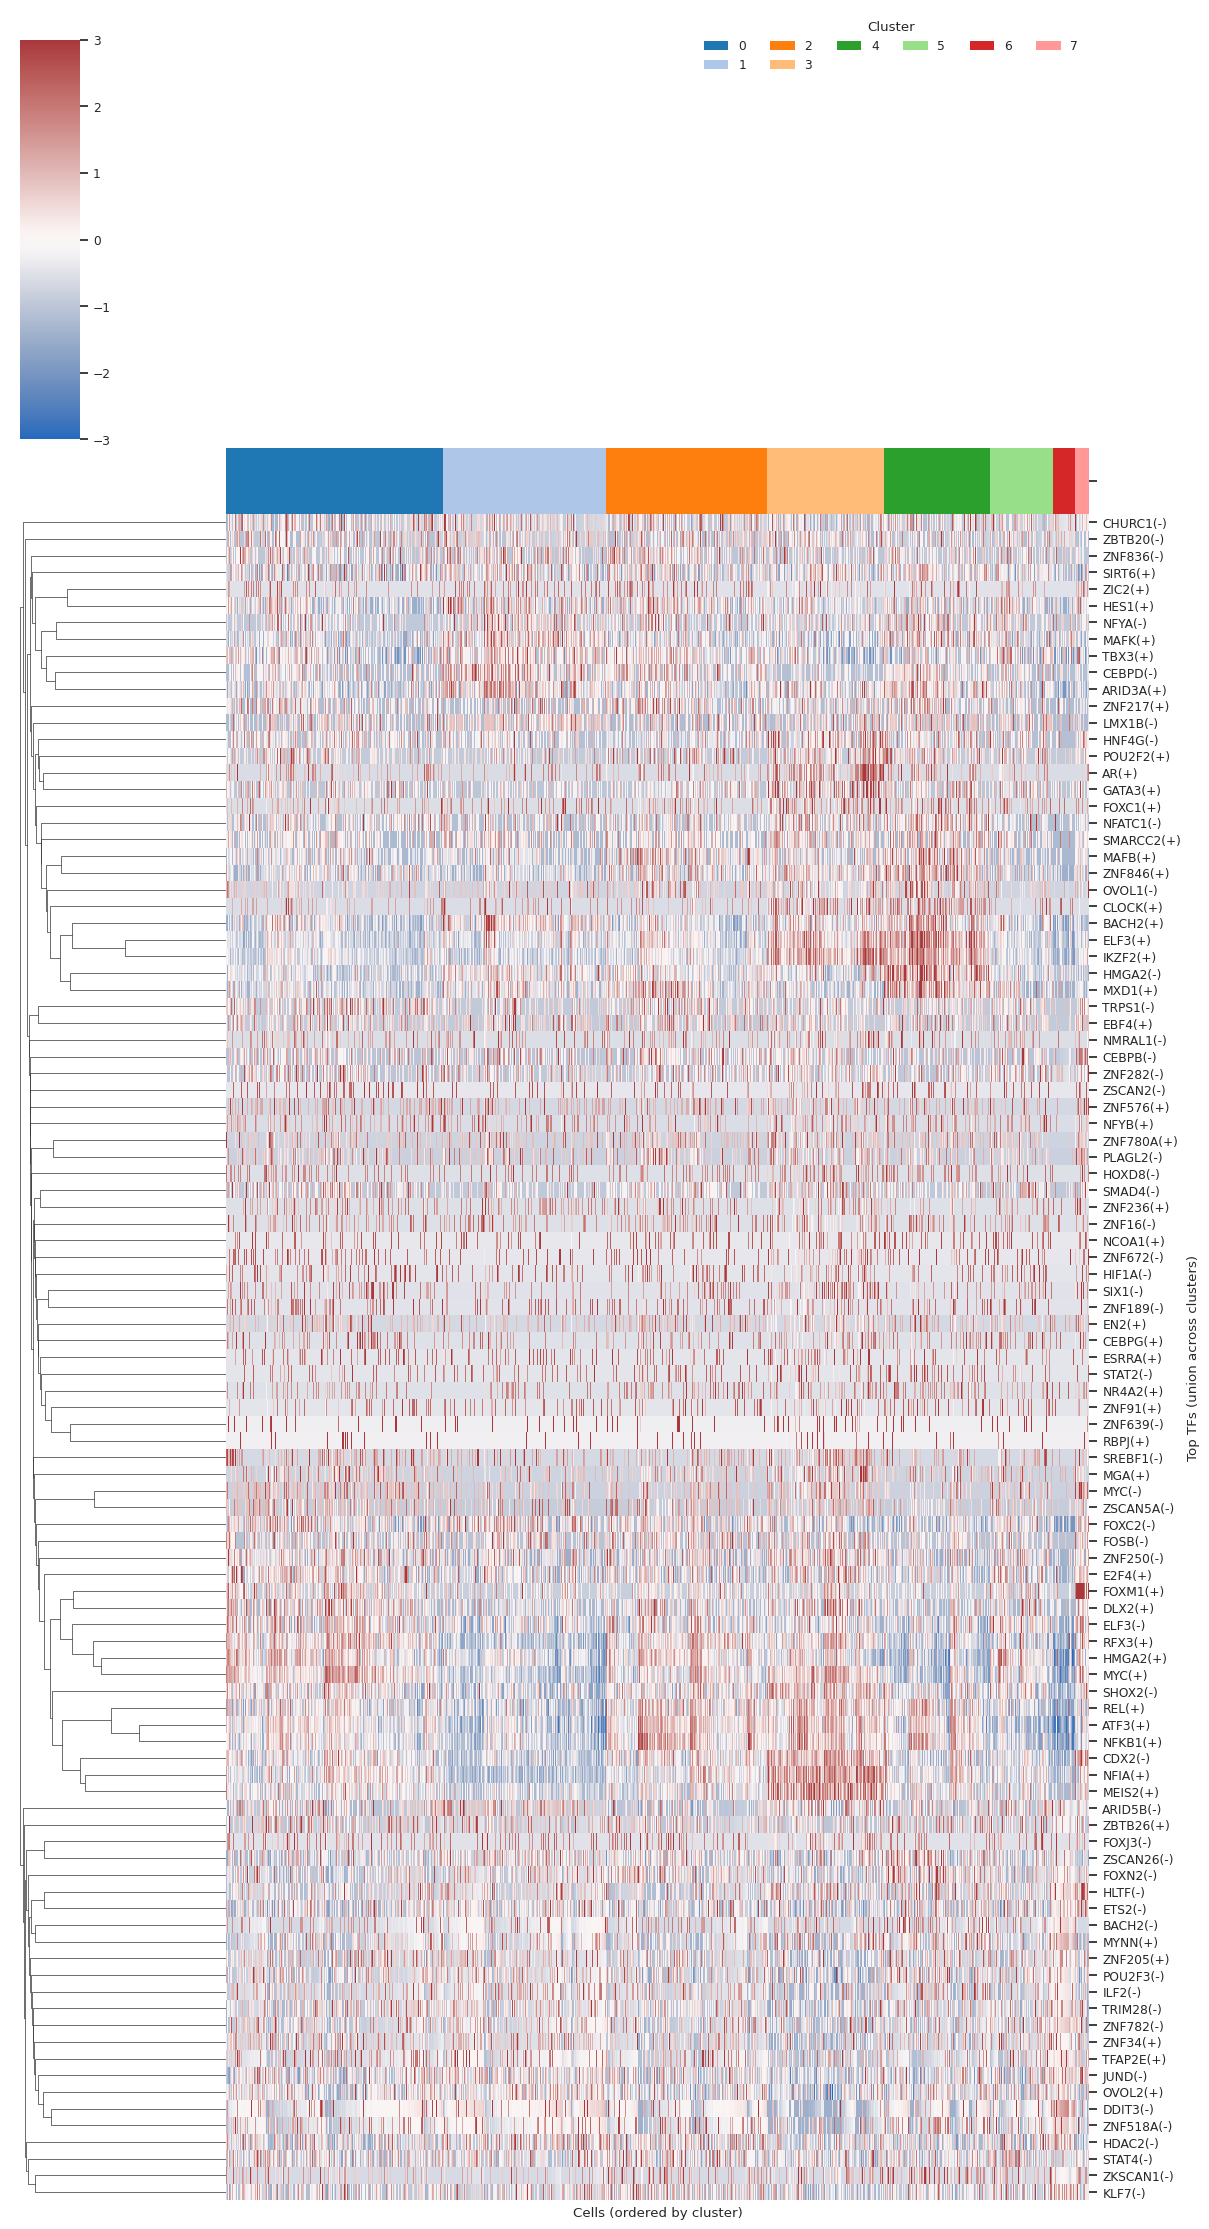

In [101]:
### per cluster z-scaled averaged AUCELL now

ordered = (
    top_table
    .sort_values(['cluster','log2FC'], ascending=[True, True])
    .drop_duplicates(subset=['TF'], keep='first')   # keep TF’s “primary” cluster
)
tf_union = ordered['TF'].tolist()

# Ensure AUCell is TFs x cells; flip if needed:
if new_auc2_filtered.columns.equals(annots_series.index):   # TFs x cells
    mat = new_auc2_filtered
else:
    mat = new_auc2_filtered.T

# subset to selected TFs in that order
have = [t for t in tf_union if t in mat.index]
Z = mat.loc[have]

# cells ordered by cluster
cluster_order = sorted(annots_series.unique(), key=str)
cells = pd.Index([c for cl in cluster_order for c in annots_series[annots_series==cl].index])
Z = Z.loc[:, cells]

# z-score per TF (row-wise) and clip
Z = ((Z.T - Z.mean(1)).T) / Z.std(1).replace(0, np.nan).values[:, None]
Z = Z.fillna(0).clip(-3, 3)

# column color bar (cluster colors)
palette = sns.color_palette("tab20", n_colors=len(cluster_order))
cl2col = dict(zip(cluster_order, palette))
col_colors = cells.to_series().map(annots_series).map(cl2col)

g = sns.clustermap(
    Z, row_cluster=True, col_cluster=False, col_colors=col_colors,
    cmap="vlag", vmin=-3, vmax=3, xticklabels=False, yticklabels=True,
    figsize=(12, max(6, 0.22*len(have)))
)
for cl, col in cl2col.items():
    g.ax_col_dendrogram.bar(0, 0, color=col, label=str(cl), linewidth=0)
g.ax_col_dendrogram.legend(title="Cluster", ncols=min(6, len(cluster_order)), frameon=False)
g.ax_heatmap.set_xlabel("Cells (ordered by cluster)")
g.ax_heatmap.set_ylabel("Top TFs (union across clusters)")
plt.show()



/tmp/ipykernel_7952/2130065930.py:10: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  M = M.groupby(annots_series.loc[M.columns], axis=1).mean()  # TFs x clusters


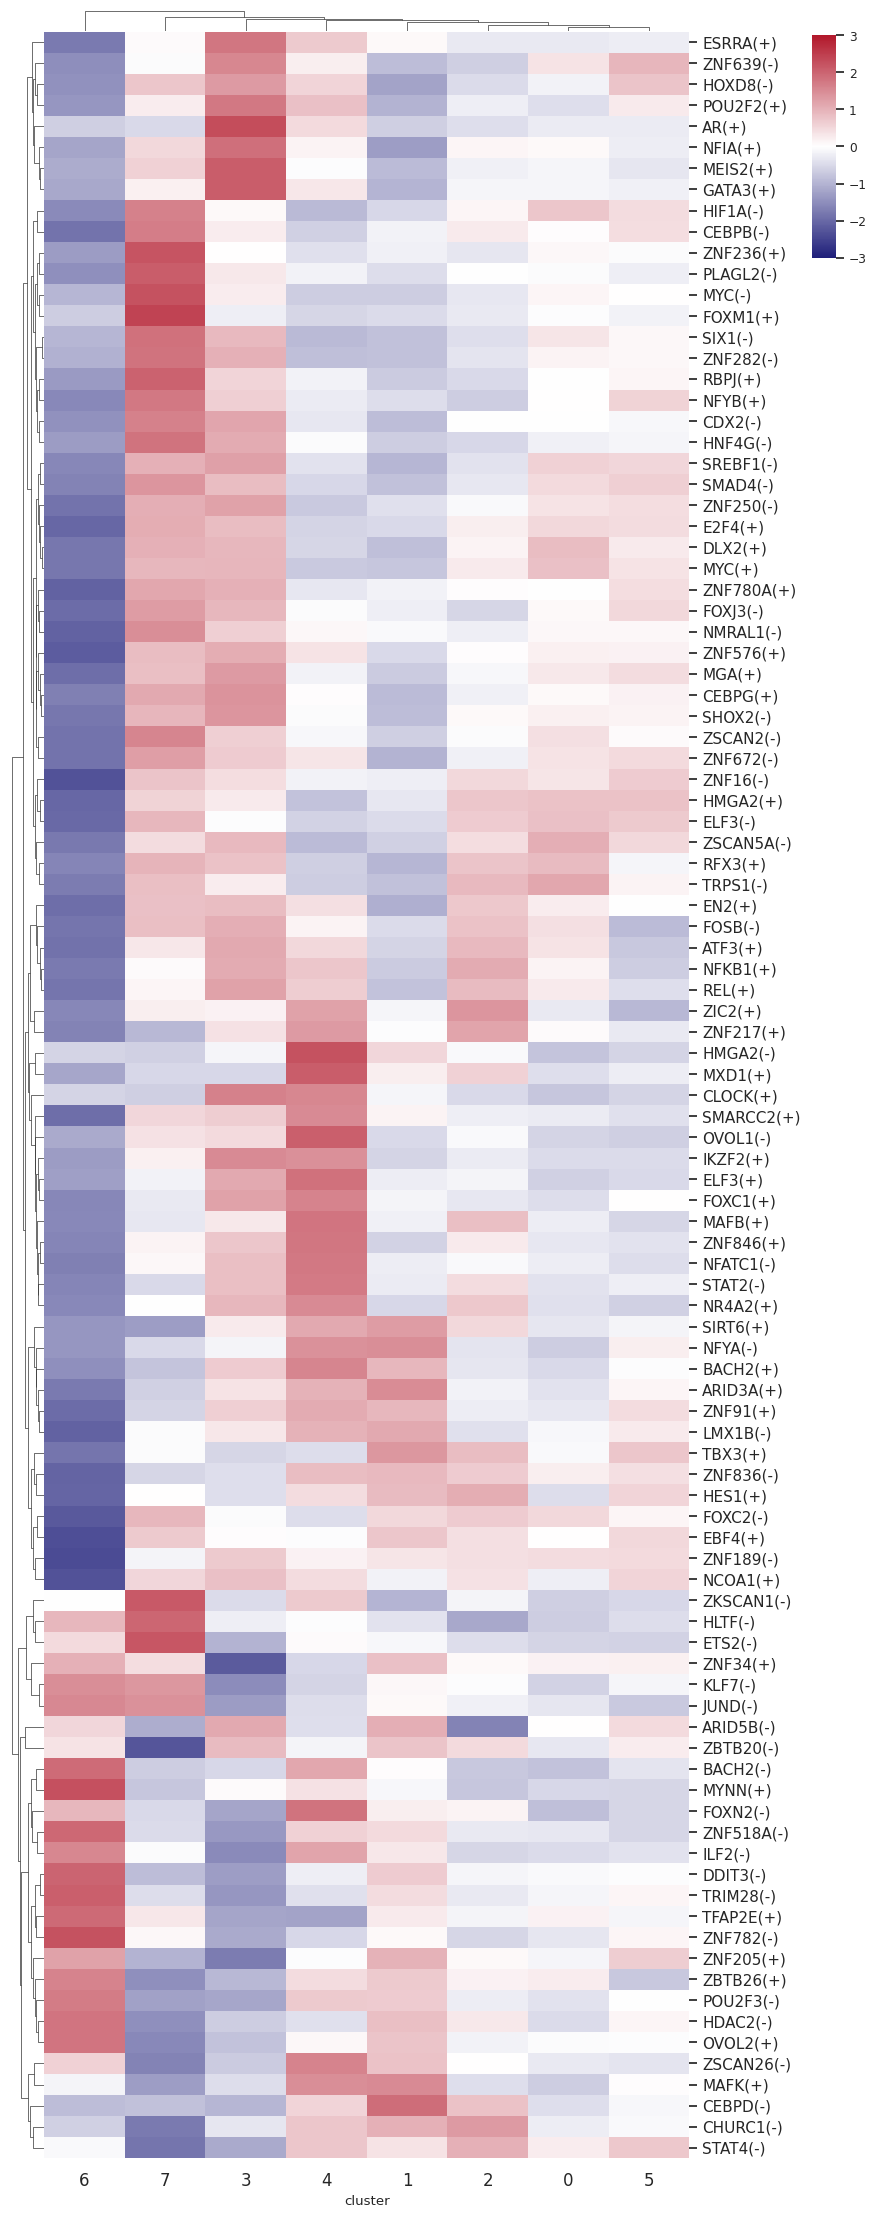

In [150]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

blue = "#1f1f7a"   # darker, saturated navy blue
red  = "#b2182b"   # darker, saturated crimson

cmap = LinearSegmentedColormap.from_list("stronger", [blue, "white", red])
norm = TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)   # keeps 0 exactly white

M = mat.loc[have, :]
M = M.groupby(annots_series.loc[M.columns], axis=1).mean()  # TFs x clusters
# z-score per TF across clusters
MZ = ((M.T - M.mean(1)).T) / M.std(1).replace(0, np.nan).values[:, None]
MZ = MZ.fillna(0).clip(-3, 3)

# cmap = sns.diverging_palette(240, 10, s=90, l=40, as_cmap=True)  

g = sns.clustermap(
        MZ,
        cmap=cmap, vmin=-3, vmax=3,
        col_cluster=True,
        figsize=(8, max(6, 0.22*len(have))),
        cbar_pos=(1.02, 0.882, 0.03, 0.1),# (x, y, width, height) in figure coords
        dendrogram_ratio=(.05, .01)
)

## Make y tick labels bold
ax = g.ax_heatmap
plt.setp(ax.get_yticklabels(), 
        #  weight='bold', 
         size=11)
plt.setp(ax.get_xticklabels(), 
        #  weight='bold', 
         size=12)

plt.savefig(os.path.join(FIGURES_FOLDERNAME, 'heatmap_Top20_TFs_Pyscenic_HumanOnly_Epi_z_scaled_by_cluster.png'), format='png', dpi=300, bbox_inches='tight')
plt.show()

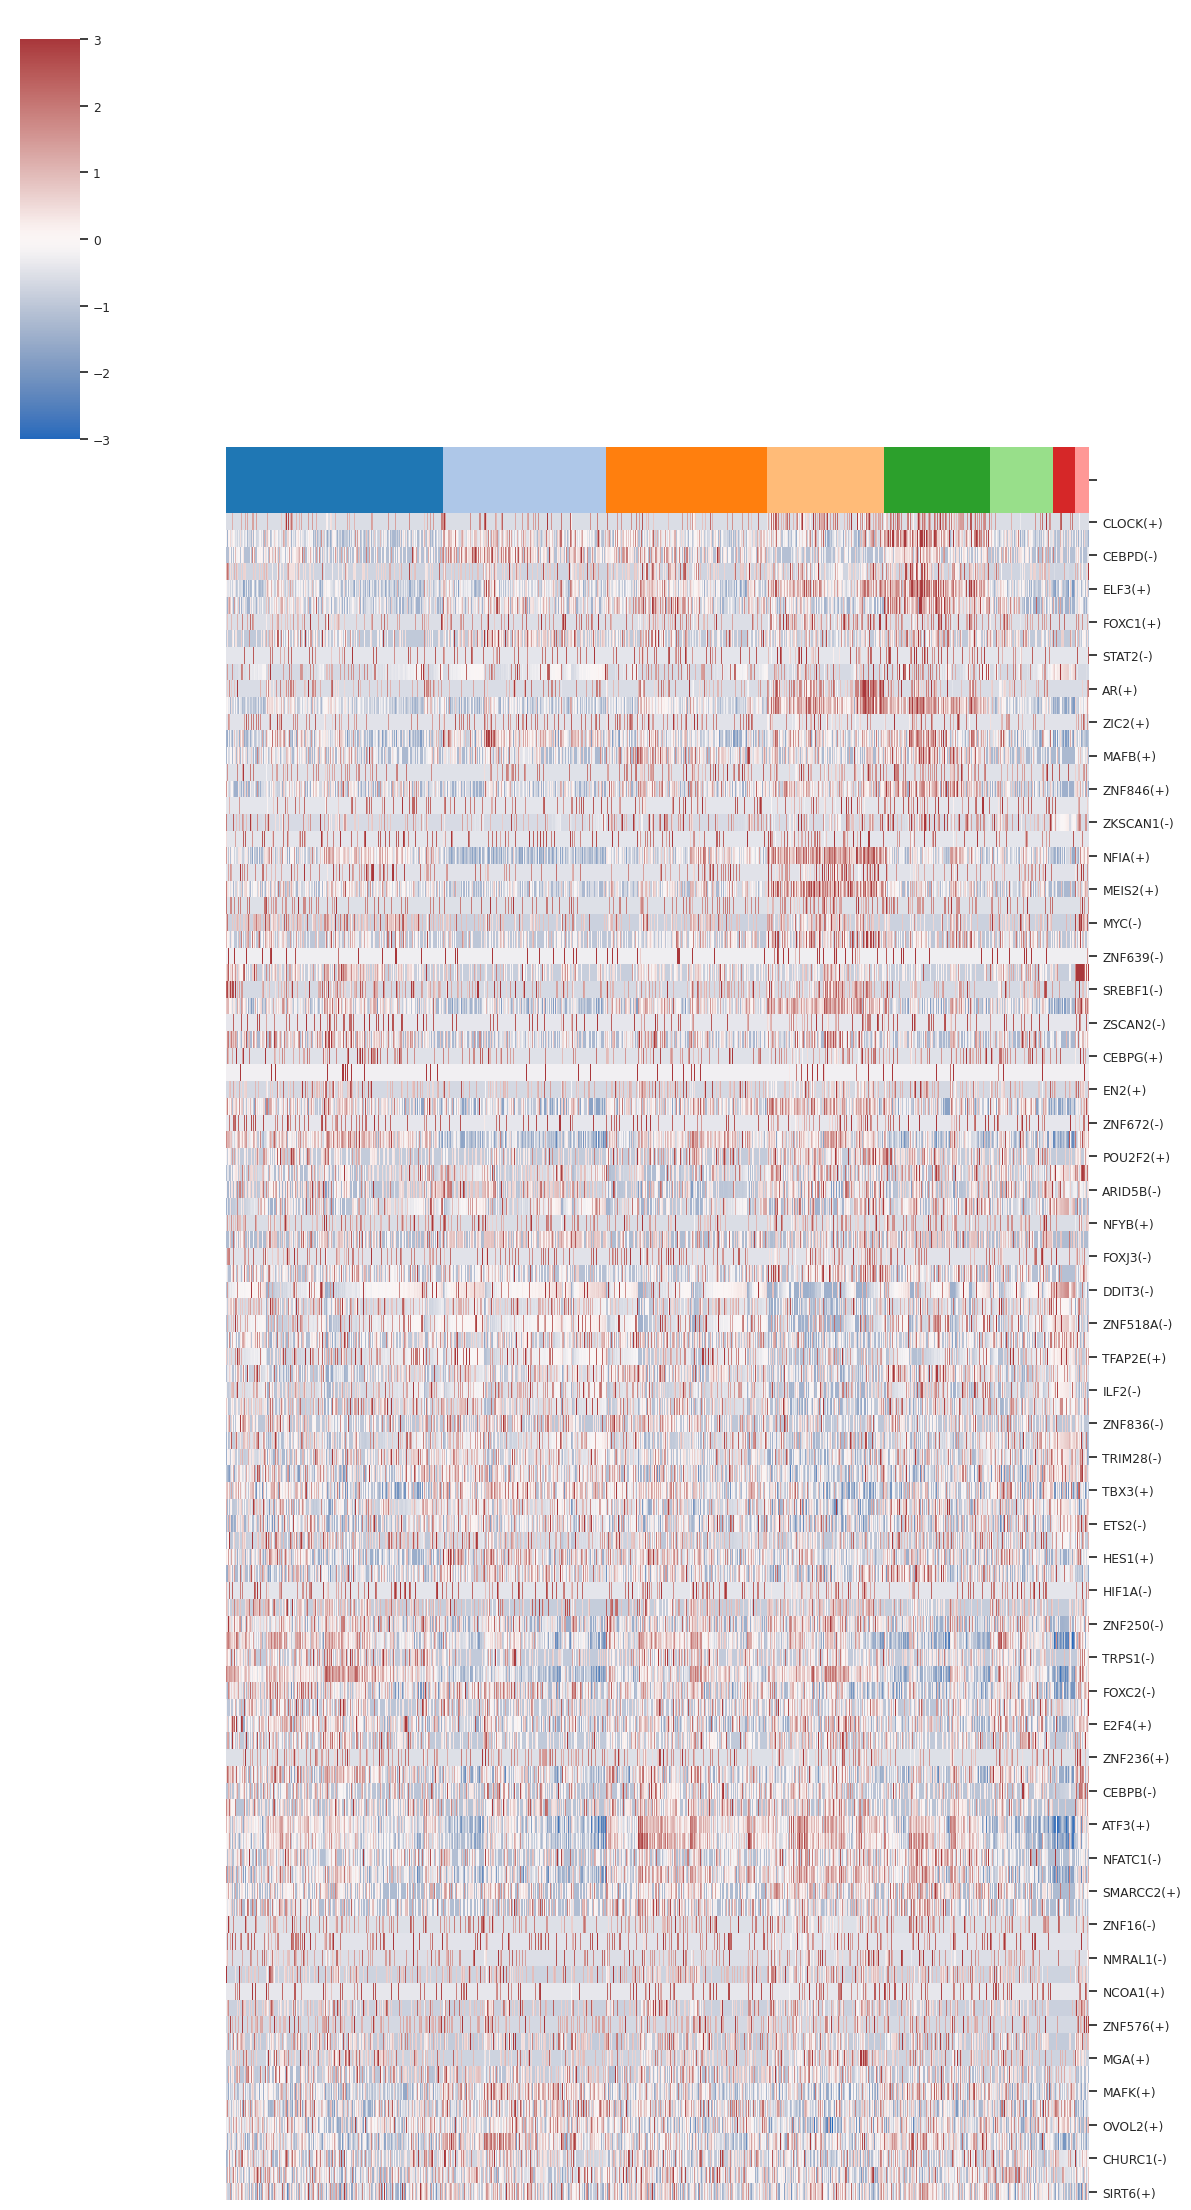

In [105]:
top_n = 20
per_cluster = (
    top_table
    .sort_values(['cluster','log2FC'])
    .groupby('cluster', group_keys=True)
    .head(top_n)
)
tf_blocked = per_cluster['TF'].tolist()   # repeated TFs allowed
# deduplicate while preserving order
seen, tf_blocked_unique = set(), []
for t in tf_blocked:
    if t not in seen and t in mat.index:
        tf_blocked_unique.append(t); seen.add(t)

Z_block = Z.loc[tf_blocked_unique]  # reuse Z computed earlier
sns.clustermap(Z_block, row_cluster=False, col_cluster=False,
               col_colors=col_colors, cmap="vlag", vmin=-3, vmax=3,
               xticklabels=False, figsize=(12, max(6, 0.22*len(tf_blocked_unique))))
plt.show()